In [5]:
%matplotlib inline

import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../../../')
sys.path.append('../../../ultralytics')

In [1]:
import ultralytics
import ultralytics.models.yolo.model

In [2]:
import torch
import random
import numpy as np

seed=0
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

In [6]:
%load_ext autoreload
%autoreload 2

from ultralytics.models.yolo.model import YOLO
from ultralytics.models.yolo.detect.predict import DetectionPredictor
    
from computer_vision.yolov11.data.utils import imread

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


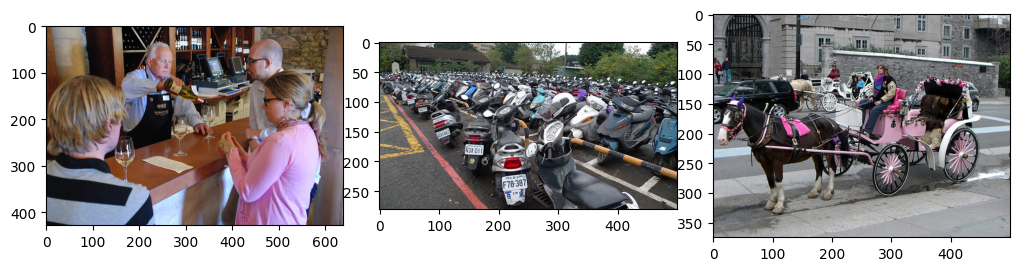

In [8]:
data_dirpath='D:/data/ultralytics/coco/images/test2017'
image_files=['000000000069.jpg', '000000000774.jpg', '000000502391.jpg']
images=[imread(os.path.join(data_dirpath, file)) for file in image_files]
_, ax=plt.subplots(1,3,figsize=(10,3))
for i, im in enumerate(images): ax[i].imshow(im[...,::-1]) # BGR to RGB
plt.tight_layout(pad=0, w_pad=0, h_pad=0)

[`stream_inference`](https://github.com/ultralytics/ultralytics/blob/main/ultralytics/engine/predictor.py) in `engine.predictor`

In [9]:
predictor = DetectionPredictor(overrides=dict(model="yolo11n.pt"))
# Load a model
predictor.model = YOLO("yolo11n.pt")  # pretrained YOLO11n model
predictor.model.fp16=False
print('predictor.model ', predictor.model.stride)
predictor.imgsz=(640,640)


predictor.model  tensor([ 8., 16., 32.])


### Preprocess images

same_shape  False
imgs_  [(640, 640, 3), (640, 640, 3), (640, 640, 3)]
imgs  (3, 640, 640, 3)
imgs  torch.Size([3, 3, 640, 640])


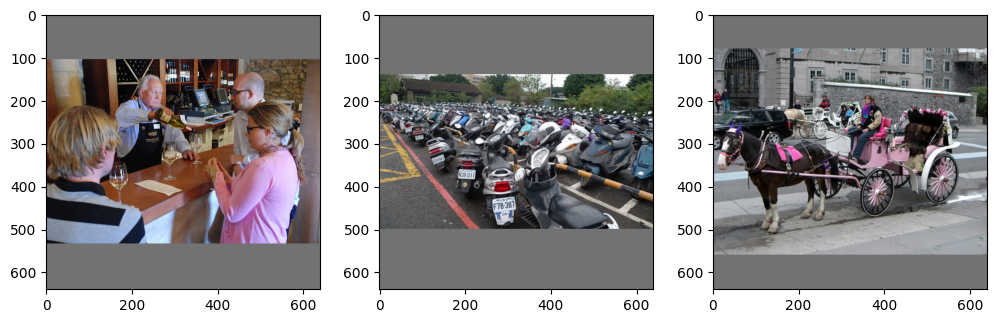

In [11]:
# preprocess
import numpy as np
from computer_vision.yolov11.data.augment import LetterBox

same_shape=len({x.shape for x in images})==1
print('same_shape ', same_shape)
letterbox=LetterBox((640,640), auto=same_shape, stride=32)
imgs_=[letterbox(image=x) for x in images]
print('imgs_ ', [i.shape for i in imgs_])

_, ax=plt.subplots(1,3,figsize=(10,3))
for i, im in enumerate(imgs_): ax[i].imshow(im[...,::-1]) # BGR to RGB
plt.tight_layout(pad=0, w_pad=0, h_pad=0)

imgs=np.stack(imgs_) # BGR
imgs=imgs[...,::-1] # BGR to RGB
print('imgs ', imgs.shape)
imgs=np.ascontiguousarray( imgs.transpose((0,3,1,2)) ) # BxHxWxC to BxCxHxW
imgs=torch.from_numpy(imgs)/255. # from 0-255 to 0-1
print('imgs ', imgs.shape)

In [14]:
predictor.model.eval()
with torch.no_grad(): preds=predictor.model._predict_once(imgs)
print('preds ', type(preds), [type(p) for p in preds])
torch.save(preds, 'ref_preds.pt')

preds  <class 'tuple'> [<class 'torch.Tensor'>, <class 'list'>]


### Post processing

In [12]:
from ultralytics.utils import nms, ops

In [15]:
preds_outs = nms.non_max_suppression(
    preds,
    predictor.args.conf,
    predictor.args.iou,
    predictor.args.classes,
    predictor.args.agnostic_nms,
    max_det=predictor.args.max_det,
    nc=0 if predictor.args.task == "detect" else len(predictor.model.names),
    end2end=getattr(predictor.model, "end2end", False),
    rotated=predictor.args.task == "obb",
    return_idxs=False,
)
print('preds_outs ',type(preds_outs), [p.shape for p in preds_outs])

preds_outs  <class 'list'> [torch.Size([10, 6]), torch.Size([8, 6]), torch.Size([11, 6])]


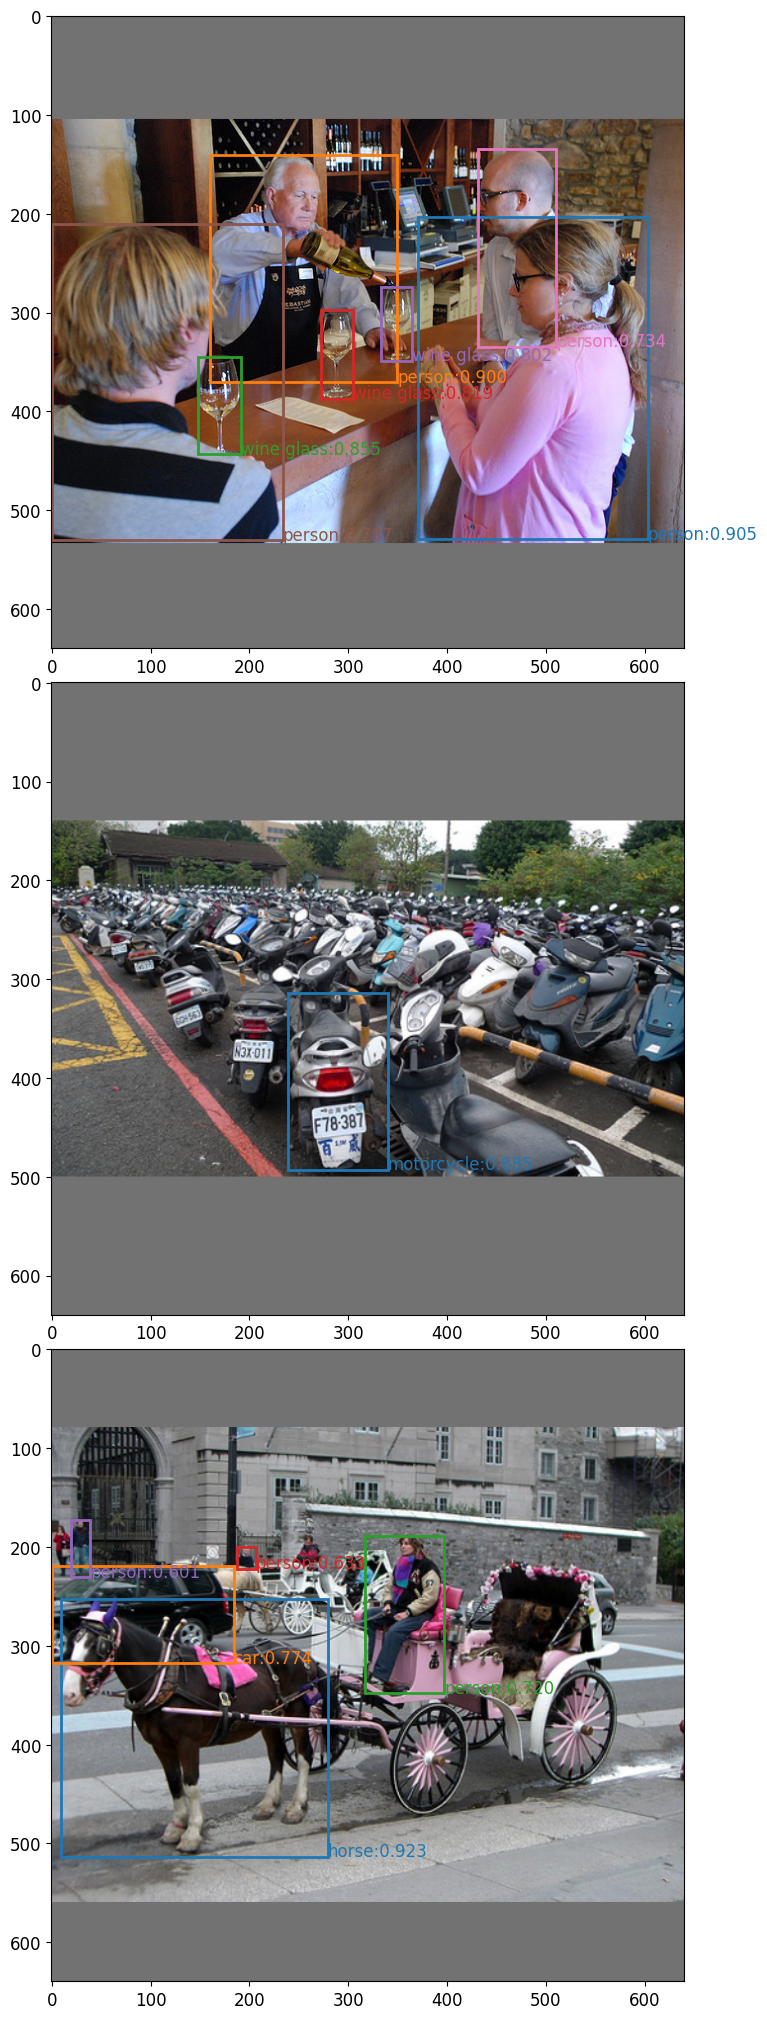

In [16]:
from matplotlib import patches
cmap = plt.get_cmap('tab10', 10)
plt.rcParams.update({'font.size'   : 12})

_, ax=plt.subplots(3,1,figsize=(20,20))

for i, (im, out) in enumerate(zip(imgs, preds_outs)):

    boxes=out[:,:4]
    confidence=out[:,-2]
    classes=[predictor.model.names[int(c)] for c in out[:,-1].tolist()]
    ax[i].imshow(im.permute(1,2,0)) # CxHxW to HxWxC
    for j, (box, conf, cls) in enumerate(zip(boxes, confidence, classes)):
        if conf < 0.6: continue # only pick confidence > 0.6
        # Create a Rectangle patch
        rect = patches.Rectangle(box[:2], box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor=cmap(j), facecolor='none')
        # Add the patch to the Axes
        ax[i].add_patch(rect)
        ax[i].text(*box[2:], f'{cls}:{conf.item():.3f}', color=cmap(j), fontsize=12)
plt.tight_layout(pad=0, w_pad=0, h_pad=0)

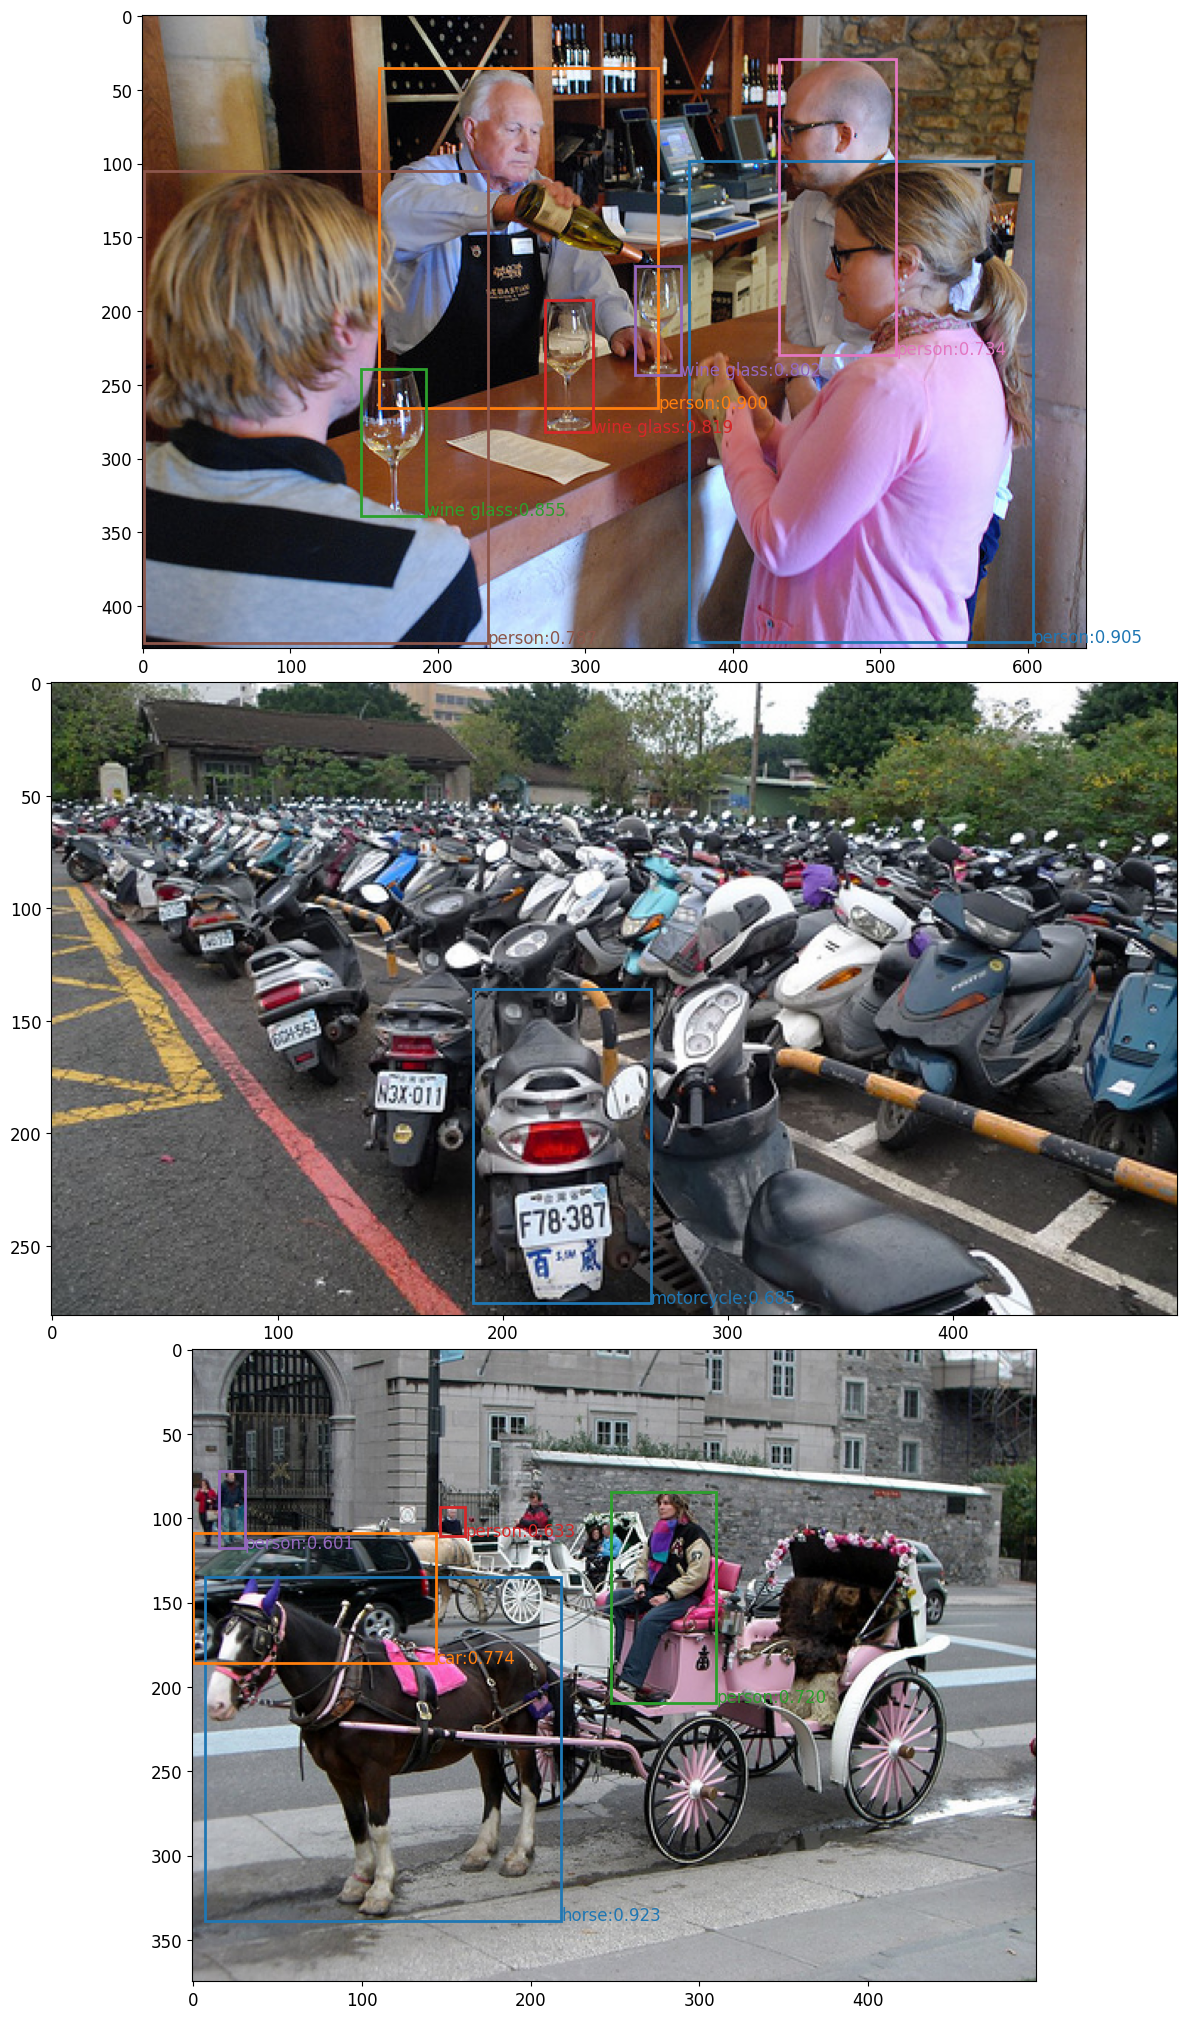

In [17]:
# adjust to old image

_, ax=plt.subplots(3,1,figsize=(20,20))
boxes_collection=dict()
for i, (im, out) in enumerate(zip(images, preds_outs)):
    boxes= ops.scale_boxes(imgs.shape[2:], out[:,:4], im.shape[:2])
    confidence=out[:,-2]
    classes=[predictor.model.names[int(c)] for c in out[:,-1].tolist()]
    ax[i].imshow(im[...,::-1]) # BGR to RGB 
    for j, (box, conf, cls) in enumerate(zip(boxes, confidence, classes)):
        if conf < 0.6: continue # only pick confidence > 0.6
        # Create a Rectangle patch
        rect = patches.Rectangle(box[:2], box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor=cmap(j), facecolor='none')
        # Add the patch to the Axes
        ax[i].add_patch(rect)
        ax[i].text(*box[2:], f'{cls}:{conf.item():.3f}', color=cmap(j), fontsize=12)
    boxes_collection[i]=boxes
plt.tight_layout(pad=0, w_pad=0, h_pad=0)
torch.save(boxes_collection, 'boxes_collection.pt')


In [18]:
output_dirpath="D:/results/yolov11/validation"

In [19]:
for name, param in predictor.model.state_dict().items():
    print(name, param.shape)
torch.save({'model':predictor.model.state_dict()}, os.path.join(output_dirpath,'predictor_yolo11n_torch.pt'))

model.model.0.conv.weight torch.Size([16, 3, 3, 3])
model.model.0.bn.weight torch.Size([16])
model.model.0.bn.bias torch.Size([16])
model.model.0.bn.running_mean torch.Size([16])
model.model.0.bn.running_var torch.Size([16])
model.model.0.bn.num_batches_tracked torch.Size([])
model.model.1.conv.weight torch.Size([32, 16, 3, 3])
model.model.1.bn.weight torch.Size([32])
model.model.1.bn.bias torch.Size([32])
model.model.1.bn.running_mean torch.Size([32])
model.model.1.bn.running_var torch.Size([32])
model.model.1.bn.num_batches_tracked torch.Size([])
model.model.2.cv1.conv.weight torch.Size([32, 32, 1, 1])
model.model.2.cv1.bn.weight torch.Size([32])
model.model.2.cv1.bn.bias torch.Size([32])
model.model.2.cv1.bn.running_mean torch.Size([32])
model.model.2.cv1.bn.running_var torch.Size([32])
model.model.2.cv1.bn.num_batches_tracked torch.Size([])
model.model.2.cv2.conv.weight torch.Size([64, 48, 1, 1])
model.model.2.cv2.bn.weight torch.Size([64])
model.model.2.cv2.bn.bias torch.Size([64]